In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

DATA_DIR = Path("data/milk10k")
IMAGE_DIR = DATA_DIR / "images"

metadata = pd.read_csv(DATA_DIR / "metadata.csv")
training_gt = pd.read_csv(DATA_DIR / "supplements" / "training_gt.csv")

print("Metadata shape:", metadata.shape)
print("Training GT shape:", training_gt.shape)

Metadata shape: (10480, 17)
Training GT shape: (5240, 12)


# PART A — PRACTISING SESSIONS 1, 2 AND 3

## A1 — Session 1: Trusting and shaping the data

### A1.1 — Cross-check the two label files

In [2]:
# (a) Same lesion_id set
metadata_lesions = set(metadata["lesion_id"].dropna())
gt_lesions = set(training_gt["lesion_id"].dropna())

missing_in_gt = metadata_lesions - gt_lesions
missing_in_metadata = gt_lesions - metadata_lesions

print("A1.1(a)")
print("Lesions in metadata:", len(metadata_lesions))
print("Lesions in training_gt:", len(gt_lesions))
print("Missing from training_gt:", len(missing_in_gt))
print("Missing from metadata:", len(missing_in_metadata))

assert metadata_lesions == gt_lesions
print("PASS: lesion_id sets are identical.")

A1.1(a)
Lesions in metadata: 5240
Lesions in training_gt: 5240
Missing from training_gt: 0
Missing from metadata: 0
PASS: lesion_id sets are identical.


In [3]:
# (b) Exactly one positive 11-class label per lesion
gt_classes = [
    "AKIEC", "BCC", "BEN_OTH", "BKL", "DF",
    "INF", "MAL_OTH", "MEL", "NV", "SCCKA", "VASC"
]

positive_counts = training_gt[gt_classes].sum(axis=1)

print("A1.1(b)")
print("Positive-class count distribution:")
print(positive_counts.value_counts().sort_index())

violations = training_gt.loc[
    positive_counts != 1,
    ["lesion_id"] + gt_classes
]

print("Number of violations:", len(violations))
if len(violations):
    display(violations)

assert (positive_counts == 1).all()
print("PASS: every lesion has exactly one positive class.")

A1.1(b)
Positive-class count distribution:
1    5240
Name: count, dtype: int64
Number of violations: 0
PASS: every lesion has exactly one positive class.


In [4]:
# (c) Each 11-class label maps to exactly one diagnosis_1
lesion_diagnosis = (
    metadata.groupby("lesion_id")["diagnosis_1"]
    .first()
    .rename("diagnosis_1")
)

gt_long = (
    training_gt[["lesion_id"] + gt_classes]
    .melt(
        id_vars="lesion_id",
        var_name="dx",
        value_name="positive"
    )
    .query("positive == 1")
    [["lesion_id", "dx"]]
)

class_mapping = gt_long.merge(
    lesion_diagnosis,
    on="lesion_id",
    how="left",
    validate="one_to_one"
)

mapping_table = (
    class_mapping
    .groupby(["dx", "diagnosis_1"])["lesion_id"]
    .nunique()
    .reset_index(name="lesion_count")
    .sort_values(["dx", "lesion_count"], ascending=[True, False])
)

display(mapping_table)

mapping_counts = mapping_table.groupby("dx")["diagnosis_1"].nunique()
violations_c = mapping_counts[mapping_counts != 1]

print("Classes with non-unique diagnosis_1 mapping:", len(violations_c))
if len(violations_c):
    display(mapping_table[mapping_table["dx"].isin(violations_c.index)])


,dx,diagnosis_1,lesion_count
1,AKIEC,Malignant,180
0,AKIEC,Indeterminate,123
2,BCC,Malignant,2522
3,BEN_OTH,Benign,44
4,BKL,Benign,544
5,DF,Benign,52
6,INF,Benign,50
7,MAL_OTH,Malignant,9
8,MEL,Malignant,450
9,NV,Benign,746


Classes with non-unique diagnosis_1 mapping: 1


,dx,diagnosis_1,lesion_count
1,AKIEC,Malignant,180
0,AKIEC,Indeterminate,123


In [5]:
# (d) diagnosis_3 -> diagnosis_2 and diagnosis_2 -> diagnosis_1
lesion_metadata = metadata.drop_duplicates("lesion_id")

mapping_3_to_2 = (
    lesion_metadata.groupby("diagnosis_3")["diagnosis_2"]
    .nunique(dropna=True)
)
mapping_2_to_1 = (
    lesion_metadata.groupby("diagnosis_2")["diagnosis_1"]
    .nunique(dropna=True)
)

violations_3_to_2 = mapping_3_to_2[mapping_3_to_2 > 1]
violations_2_to_1 = mapping_2_to_1[mapping_2_to_1 > 1]

print("diagnosis_3 values mapping to multiple diagnosis_2 values:", len(violations_3_to_2))
print("diagnosis_2 values mapping to multiple diagnosis_1 values:", len(violations_2_to_1))

if len(violations_3_to_2):
    display(violations_3_to_2)
if len(violations_2_to_1):
    display(violations_2_to_1)

assert len(violations_3_to_2) == 0
assert len(violations_2_to_1) == 0

diagnosis_3 values mapping to multiple diagnosis_2 values: 0
diagnosis_2 values mapping to multiple diagnosis_1 values: 0


In [6]:
# (e) The two images of each lesion must agree on age, sex, site and diagnosis fields
check_columns = [
    "age_approx", "sex", "anatom_site_general",
    "diagnosis_1", "diagnosis_2", "diagnosis_3", "diagnosis_4"
]

consistency = metadata.groupby("lesion_id")[check_columns].nunique(dropna=False)

violations_e = {
    column: int((consistency[column] > 1).sum())
    for column in check_columns
}

print("Inconsistent lesions by field:")
print(violations_e)

assert all(count == 0 for count in violations_e.values())
print("PASS: paired images have identical required metadata.")

Inconsistent lesions by field:
{'age_approx': 0, 'sex': 0, 'anatom_site_general': 0, 'diagnosis_1': 0, 'diagnosis_2': 0, 'diagnosis_3': 0, 'diagnosis_4': 0}
PASS: paired images have identical required metadata.


### A1.1 — Conclusion

The two label files describe the same 5,240 lesions, and every lesion has exactly one positive 11-class ground-truth label. Each 11-class label maps to exactly one `diagnosis_1` category, so the three-class target can be derived consistently from the detailed labels. The diagnosis hierarchy is also consistent, and the two images of each lesion agree on age, sex, site, and diagnosis fields. These checks should be repeated on any new medical dataset before training; the most dangerous failure would be inconsistent or incorrect labels because they can silently corrupt both training and evaluation.

### A1.2 — Ask the data five questions

In [7]:
# One row per image, with its 11-class label
image_labels = (
    gt_long
    .merge(metadata[["lesion_id", "isic_id", "age_approx", "anatom_site_general",
                     "image_manipulation", "diagnosis_1", "diagnosis_confirm_type"]],
           on="lesion_id", how="inner")
)

# Q1 — BCC lesions, age >= 70, head/neck
q1 = metadata.merge(
    training_gt[["lesion_id", "BCC"]],
    on="lesion_id",
    how="inner"
).query(
    "BCC == 1 and age_approx >= 70 and anatom_site_general == 'head/neck'"
)

print("Q1 — BCC lesions aged 70+ on head/neck:", q1["lesion_id"].nunique())

Q1 — BCC lesions aged 70+ on head/neck: 380


In [8]:
# Q2 — 11-class with highest percentage of altered images
q2 = (
    image_labels.groupby("dx")["image_manipulation"]
    .apply(lambda x: (x == "altered").mean() * 100)
    .sort_values(ascending=False)
)

print("Q2 — Percentage altered by 11-class:")
print(q2)
print(f"Answer: {q2.index[0]} ({q2.iloc[0]:.2f}%)")

Q2 — Percentage altered by 11-class:
dx
BEN_OTH    18.181818
INF         8.000000
AKIEC       7.095710
MEL         6.333333
VASC        4.255319
NV          4.021448
BKL         3.952206
DF          1.923077
BCC         1.823949
SCCKA       1.057082
MAL_OTH     0.000000
Name: image_manipulation, dtype: float64
Answer: BEN_OTH (18.18%)


In [9]:
# Q3 — youngest/oldest patient with melanoma (MEL)
mel = image_labels[image_labels["dx"] == "MEL"]

youngest = mel["age_approx"].min()
oldest = mel["age_approx"].max()

print("Q3 — Youngest:", youngest)
print("Q3 — Oldest:", oldest)
print("Q3 — Gap:", oldest - youngest, "years")

Q3 — Youngest: 20.0
Q3 — Oldest: 85.0
Q3 — Gap: 65.0 years


In [10]:
# Q4 — Is missing anatom_site_general informative?
q4 = image_labels.drop_duplicates("lesion_id").copy()
q4["site_missing"] = q4["anatom_site_general"].isna()

with_site = (
    q4[~q4["site_missing"]]
    .groupby("dx")["lesion_id"].count()
)
without_site = (
    q4[q4["site_missing"]]
    .groupby("dx")["lesion_id"].count()
)

q4_distribution = pd.DataFrame({
    "With recorded site (%)": 100 * with_site / with_site.sum(),
    "Without recorded site (%)": 100 * without_site / without_site.sum()
}).fillna(0)

q4_distribution["Difference (percentage points)"] = (
    q4_distribution["With recorded site (%)"]
    - q4_distribution["Without recorded site (%)"]
).abs()

q4_distribution = q4_distribution.sort_values(
    "Difference (percentage points)", ascending=False
)

display(q4_distribution)
print("Q4 — Largest class difference:", q4_distribution.index[0])
print("Percentage-point difference:",
      f"{q4_distribution.iloc[0]['Difference (percentage points)']:.2f}")

,With recorded site (%),Without recorded site (%),Difference (percentage points)
dx,,,
NV,10.140073,21.114519,10.974446
SCCKA,12.697929,2.862986,9.834944
AKIEC,8.008526,2.044990,5.963536
MEL,7.155907,10.991820,3.835913
BCC,47.411693,49.335378,1.923685
DF,1.309379,0.460123,0.849256
BKL,10.566382,10.071575,0.494808
VASC,0.730816,1.175869,0.445053
MAL_OTH,0.091352,0.306748,0.215396


Q4 — Largest class difference: NV
Percentage-point difference: 10.97


In [11]:
# Q5 — Percentage Malignant by diagnosis_confirm_type
q5 = metadata.drop_duplicates("lesion_id")

malignant_by_confirmation = (
    q5.groupby("diagnosis_confirm_type")["diagnosis_1"]
    .apply(lambda x: (x == "Malignant").mean() * 100)
)

print("Q5 — Percentage Malignant by confirmation type:")
print(malignant_by_confirmation)

Q5 — Percentage Malignant by confirmation type:
diagnosis_confirm_type
histopathology                            72.348485
single contributor clinical assessment     2.232143
Name: diagnosis_1, dtype: float64


**Q5 interpretation:** The percentage of Malignant lesions differs strongly by confirmation type. In particular, histopathology-confirmed lesions have a much higher malignant proportion than lesions confirmed by clinical assessment. This suggests that the dataset is not a simple random sample of all skin lesions: the route by which a lesion was confirmed is associated with which diagnoses enter the dataset.

### A1.3 — Build the lesion-level table

In [12]:
# One row per lesion, with dermoscopic and clinical image IDs
image_table = metadata[
    ["lesion_id", "image_type", "isic_id"]
].copy()

lesion_images = (
    image_table
    .pivot(index="lesion_id", columns="image_type", values="isic_id")
    .rename(columns={
        "dermoscopic": "derm_id",
        "clinical: close-up": "clinical_id"
    })
    .reset_index()
)

# One row per lesion for metadata
lesion_meta = (
    metadata
    .drop_duplicates("lesion_id")
    [["lesion_id", "diagnosis_1", "age_approx", "sex", "anatom_site_general"]]
    .rename(columns={
        "age_approx": "age",
        "anatom_site_general": "site"
    })
)

# Add the 11-class label
lesion_dx = (
    gt_long[["lesion_id", "dx"]]
    .drop_duplicates("lesion_id")
)

lesion_table = (
    lesion_images
    .merge(lesion_meta, on="lesion_id", how="inner", validate="one_to_one")
    .merge(lesion_dx, on="lesion_id", how="inner", validate="one_to_one")
)

lesion_table = lesion_table[
    ["lesion_id", "derm_id", "clinical_id",
     "diagnosis_1", "dx", "age", "sex", "site"]
]

print("Shape:", lesion_table.shape)
display(lesion_table.head())

assert len(lesion_table) == 5240
assert lesion_table["lesion_id"].is_unique
assert lesion_table["derm_id"].notna().all()
assert lesion_table["clinical_id"].notna().all()

lesion_table.to_csv("lesion_table.csv", index=False)
print("PASS: lesion_table has 5,240 unique lesions and both image IDs.")
print("Saved: lesion_table.csv")

Shape: (5240, 8)


,lesion_id,derm_id,clinical_id,diagnosis_1,dx,age,sex,site
0,IL_0000652,ISIC_4671410,ISIC_8149219,Malignant,BCC,70.0,male,head/neck
1,IL_0003176,ISIC_5371928,ISIC_3904045,Malignant,BCC,45.0,female,head/neck
2,IL_0004688,ISIC_3624913,ISIC_0791494,Malignant,BCC,50.0,male,lower extremity
3,IL_0005081,ISIC_5186409,ISIC_5667730,Malignant,SCCKA,45.0,male,head/neck
4,IL_0006177,ISIC_1048297,ISIC_8803389,Malignant,BCC,75.0,male,upper extremity


PASS: lesion_table has 5,240 unique lesions and both image IDs.
Saved: lesion_table.csv


### A1.4 — Task framing

The project classifies each skin lesion as Benign, Malignant, or Indeterminate using its dermoscopic and clinical images, with metadata available as contextual information. The output is a lesion-level class prediction that could support clinical assessment at the point when a lesion is being evaluated. I would optimise balanced accuracy because the classes are imbalanced and each class should contribute equally to the evaluation. A false negative for a Malignant lesion is more costly because it can delay appropriate follow-up. Compared with real-world use, MILK10k is a curated dataset with fixed paired image types, whereas clinical practice can have greater variation in image acquisition and may not always provide both views.

## A2 — Session 2: Working with pixels

### A2.1 — Arrays, views and memory

In [13]:
# Load one dermoscopic image
lesion_id = lesion_table.iloc[0]["lesion_id"]
derm_id = lesion_table.iloc[0]["derm_id"]
image_path = IMAGE_DIR / f"{derm_id}.jpg"

img = np.array(Image.open(image_path).convert("RGB"))
print("Image shape:", img.shape)
print("Image dtype:", img.dtype)

Image shape: (450, 600, 3)
Image dtype: uint8


In [14]:
# (a) NumPy-only transformations
flip_lr = np.fliplr(img)
flip_ud = np.flipud(img)
rotate_90 = np.rot90(img, k=1)
transpose = np.transpose(img, (1, 0, 2))

# Verify against Pillow
pil_img = Image.fromarray(img)

pil_lr = np.array(pil_img.transpose(Image.Transpose.FLIP_LEFT_RIGHT))
pil_ud = np.array(pil_img.transpose(Image.Transpose.FLIP_TOP_BOTTOM))
pil_rot90 = np.array(pil_img.transpose(Image.Transpose.ROTATE_90))
pil_transpose = np.array(pil_img.transpose(Image.Transpose.TRANSPOSE))

checks = {
    "left-right flip": np.array_equal(flip_lr, pil_lr),
    "up-down flip": np.array_equal(flip_ud, pil_ud),
    "90-degree rotation": np.array_equal(rotate_90, pil_rot90),
    "transpose": np.array_equal(transpose, pil_transpose),
}

print(checks)
assert all(checks.values())

{'left-right flip': True, 'up-down flip': True, '90-degree rotation': True, 'transpose': True}


In [15]:
# (b) View/copy check and modification experiment
shares = {
    "left-right flip": np.shares_memory(img, flip_lr),
    "up-down flip": np.shares_memory(img, flip_ud),
    "90-degree rotation": np.shares_memory(img, rotate_90),
    "transpose": np.shares_memory(img, transpose),
}

print("Shares memory:", shares)

# Demonstrate what happens when a view is modified.
small = np.arange(9).reshape(3, 3)
view = small.T
before = small.copy()
view[0, 1] = 999

print("Original before modification:")
print(before)
print("Original after modifying the view:")
print(small)

assert small[1, 0] == 999

Shares memory: {'left-right flip': True, 'up-down flip': True, '90-degree rotation': True, 'transpose': True}
Original before modification:
[[0 1 2]
 [3 4 5]
 [6 7 8]]
Original after modifying the view:
[[  0   1   2]
 [999   4   5]
 [  6   7   8]]


In [16]:
# (c) Memory budget for all 10,480 images
n_images = 10480
height, width, channels = img.shape

memory = {
    "uint8 original": n_images * height * width * channels * np.dtype(np.uint8).itemsize,
    "float32 original": n_images * height * width * channels * np.dtype(np.float32).itemsize,
    "uint8 224x224": n_images * 224 * 224 * channels * np.dtype(np.uint8).itemsize,
    "float32 224x224": n_images * 224 * 224 * channels * np.dtype(np.float32).itemsize,
}

memory_gb = {k: v / (1024**3) for k, v in memory.items()}
for key, value in memory_gb.items():
    print(f"{key}: {value:.2f} GB")

print(
    "A full preload is not practical at the original resolution; "
    "a 224x224 uint8 array is much smaller, but an on-demand DataLoader "
    "is preferable because it avoids keeping the whole dataset in RAM."
)

uint8 original: 7.91 GB
float32 original: 31.62 GB
uint8 224x224: 1.47 GB
float32 224x224: 5.88 GB
A full preload is not practical at the original resolution; a 224x224 uint8 array is much smaller, but an on-demand DataLoader is preferable because it avoids keeping the whole dataset in RAM.


### A2.2 — JPEG compression and file-size shortcut

In [17]:
# (a) Re-encode one image at five JPEG qualities and compute PSNR
import io

def psnr(original, compressed):
    original = original.astype(np.float64)
    compressed = compressed.astype(np.float64)
    mse = np.mean((original - compressed) ** 2)
    if mse == 0:
        return float("inf")
    return 10 * np.log10((255 ** 2) / mse)

original_img = Image.open(image_path).convert("RGB")
original_array = np.array(original_img)

jpeg_records = []
compressed_images = {}

for quality in [95, 75, 50, 25, 10]:
    buffer = io.BytesIO()
    original_img.save(buffer, format="JPEG", quality=quality)
    size_kb = buffer.tell() / 1024

    buffer.seek(0)
    compressed = Image.open(buffer).convert("RGB")
    compressed_array = np.array(compressed)

    jpeg_records.append({
        "quality": quality,
        "file_size_kb": size_kb,
        "PSNR_dB": psnr(original_array, compressed_array)
    })

    if quality in [95, 10]:
        compressed_images[quality] = compressed_array

jpeg_results = pd.DataFrame(jpeg_records)
display(jpeg_results)

,quality,file_size_kb,PSNR_dB
0,95,55.604492,51.907230
1,75,29.074219,68.798931
2,50,22.741211,37.222827
3,25,11.738281,34.626509
4,10,6.542969,30.919728


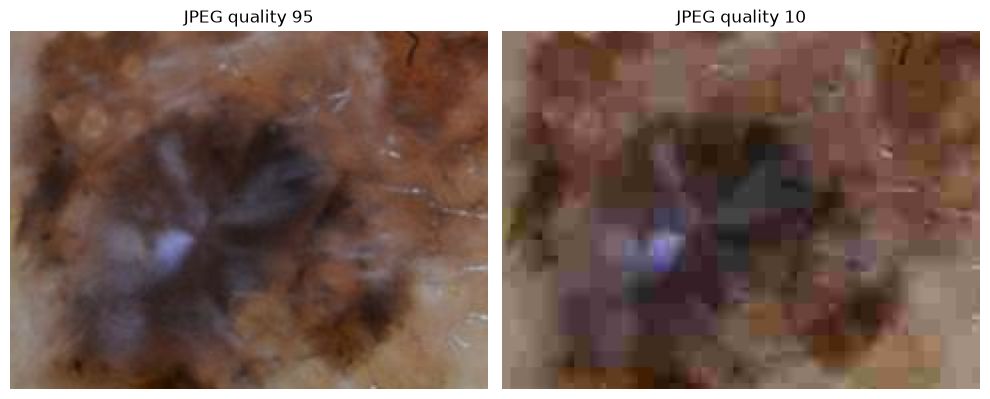

In [18]:
# Show a zoomed crop of the best and worst quality
h, w = original_array.shape[:2]
y1, y2 = int(0.30 * h), int(0.70 * h)
x1, x2 = int(0.30 * w), int(0.70 * w)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(compressed_images[95][y1:y2, x1:x2])
axes[0].set_title("JPEG quality 95")
axes[0].axis("off")

axes[1].imshow(compressed_images[10][y1:y2, x1:x2])
axes[1].set_title("JPEG quality 10")
axes[1].axis("off")

plt.tight_layout()
plt.show()

**A2.2(b) Interpretation:** MILK10k images are already JPEG-compressed, so the model is learning from images that already contain compression artefacts. Re-encoding them can introduce additional compression artefacts and double compression, while resizing after compression changes the pixel structure again. Preprocessing should therefore avoid unnecessary repeated JPEG encoding.

In [19]:
# (c) File size of every image, without decoding
file_records = []

for _, row in lesion_table.iterrows():
    for image_type, id_col in [("derm", "derm_id"), ("clinical", "clinical_id")]:
        path = IMAGE_DIR / f"{row[id_col]}.jpg"
        assert path.exists(), f"Missing image: {path}"

        file_records.append({
            "lesion_id": row["lesion_id"],
            "image_type": image_type,
            "image_id": row[id_col],
            "diagnosis_1": row["diagnosis_1"],
            "file_size_kb": path.stat().st_size / 1024
        })

file_sizes = pd.DataFrame(file_records)

print("Number of images:", len(file_sizes))
assert len(file_sizes) == 10480
display(file_sizes.head())

Number of images: 10480


,lesion_id,image_type,image_id,diagnosis_1,file_size_kb
0,IL_0000652,derm,ISIC_4671410,Malignant,32.170898
1,IL_0000652,clinical,ISIC_8149219,Malignant,23.040039
2,IL_0003176,derm,ISIC_5371928,Malignant,33.188477
3,IL_0003176,clinical,ISIC_3904045,Malignant,57.780273
4,IL_0004688,derm,ISIC_3624913,Malignant,26.150391


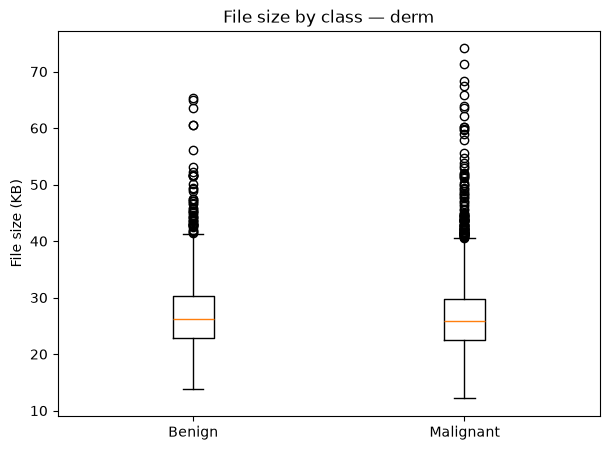

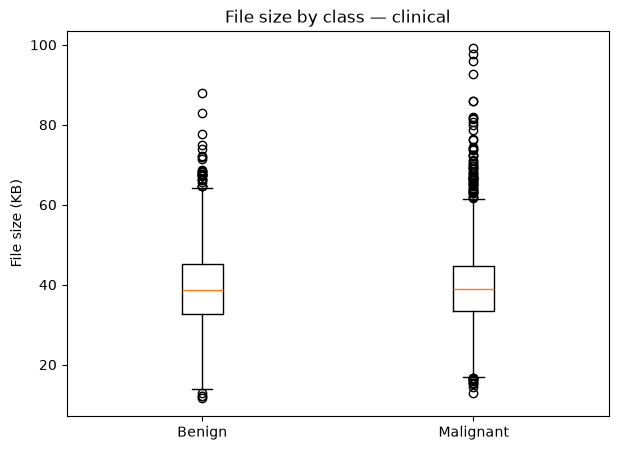

In [20]:
# Compare Benign vs Malignant file-size distributions separately by image type
for image_type in ["derm", "clinical"]:
    subset = file_sizes[
        (file_sizes["image_type"] == image_type) &
        (file_sizes["diagnosis_1"].isin(["Benign", "Malignant"]))
    ]

    benign_sizes = subset.loc[
        subset["diagnosis_1"] == "Benign", "file_size_kb"
    ]
    malignant_sizes = subset.loc[
        subset["diagnosis_1"] == "Malignant", "file_size_kb"
    ]

    plt.figure(figsize=(7, 5))
    plt.boxplot(
        [benign_sizes, malignant_sizes],
        tick_labels=["Benign", "Malignant"]
    )
    plt.ylabel("File size (KB)")
    plt.title(f"File size by class — {image_type}")
    plt.show()

In [21]:
# ROC-AUC of file size as a malignancy score, separately by image type
from sklearn.metrics import roc_auc_score

for image_type in ["derm", "clinical"]:
    subset = file_sizes[
        (file_sizes["image_type"] == image_type) &
        (file_sizes["diagnosis_1"].isin(["Benign", "Malignant"]))
    ].copy()

    y = (subset["diagnosis_1"] == "Malignant").astype(int)
    auc = roc_auc_score(y, subset["file_size_kb"])

    print(f"{image_type} ROC-AUC using file size: {auc:.4f}")

derm ROC-AUC using file size: 0.4811
clinical ROC-AUC using file size: 0.5051


**A2.2(c) Interpretation:** File size can act as a shortcut if acquisition or encoding choices differ systematically between classes. Differences can arise from camera/device settings, image resolution, JPEG quality, cropping, background content, or other acquisition and storage choices. A model that relies on file size rather than lesion appearance may fail when those acquisition conditions change.

## A3 — Session 3: Splits, imbalance, leakage, augmentation, datasets

### A3.1 — Measure the leak

In [22]:
from sklearn.model_selection import train_test_split, StratifiedGroupKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score

df = metadata.copy()

feature_cols = [
    "age_approx",
    "sex",
    "anatom_site_general",
    "image_type"
]
target_col = "diagnosis_1"
group_col = "lesion_id"

X = df[feature_cols]
y = df[target_col]

numeric_features = ["age_approx"]
categorical_features = ["sex", "anatom_site_general", "image_type"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ]), numeric_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features)
])

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        min_samples_leaf=1,
        n_jobs=-1,
        random_state=0
    ))
])

In [23]:
# (a) Naive image-level split: 5 seeds
seeds = [0, 1, 2, 3, 4]
naive_scores = []

for seed in seeds:
    train_idx, test_idx = train_test_split(
        np.arange(len(df)),
        test_size=0.20,
        random_state=seed,
        stratify=y
    )

    pipeline.set_params(model__random_state=seed)
    pipeline.fit(X.iloc[train_idx], y.iloc[train_idx])
    pred = pipeline.predict(X.iloc[test_idx])

    naive_scores.append(
        balanced_accuracy_score(y.iloc[test_idx], pred)
    )

print("Naive image-level:")
print(f"Mean balanced accuracy: {np.mean(naive_scores):.4f}")
print(f"Std: {np.std(naive_scores):.4f}")

Naive image-level:
Mean balanced accuracy: 0.4242
Std: 0.0058


In [24]:
# (b) Grouped lesion-level split: 5 seeds
grouped_scores = []

for seed in seeds:
    sgkf = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=seed
    )

    train_idx, test_idx = next(
        sgkf.split(X, y, groups=df[group_col])
    )

    pipeline.set_params(model__random_state=seed)
    pipeline.fit(X.iloc[train_idx], y.iloc[train_idx])
    pred = pipeline.predict(X.iloc[test_idx])

    grouped_scores.append(
        balanced_accuracy_score(y.iloc[test_idx], pred)
    )

print("Grouped lesion-level:")
print(f"Mean balanced accuracy: {np.mean(grouped_scores):.4f}")
print(f"Std: {np.std(grouped_scores):.4f}")

display(pd.DataFrame({
    "Split": ["Naive image-level", "Grouped lesion-level"],
    "Mean balanced accuracy": [
        np.mean(naive_scores), np.mean(grouped_scores)
    ],
    "Std": [np.std(naive_scores), np.std(grouped_scores)]
}))

Grouped lesion-level:
Mean balanced accuracy: 0.4261
Std: 0.0044


,Split,Mean balanced accuracy,Std
0,Naive image-level,0.424228,0.005812
1,Grouped lesion-level,0.426104,0.004371


In [25]:
# (c) Sibling oracle
def sibling_oracle_score(train_idx, test_idx):
    train_df = df.iloc[train_idx]
    test_df = df.iloc[test_idx]

    majority_class = train_df[target_col].mode()[0]

    train_lesion_labels = (
        train_df.groupby(group_col)[target_col]
        .first()
        .to_dict()
    )

    predictions = []
    sibling_in_train = []

    for _, row in test_df.iterrows():
        lesion = row[group_col]

        if lesion in train_lesion_labels:
            predictions.append(train_lesion_labels[lesion])
            sibling_in_train.append(True)
        else:
            predictions.append(majority_class)
            sibling_in_train.append(False)

    score = balanced_accuracy_score(test_df[target_col], predictions)
    percentage = 100 * np.mean(sibling_in_train)

    return score, percentage

oracle_naive = []
oracle_grouped = []

for seed in seeds:
    train_idx, test_idx = train_test_split(
        np.arange(len(df)),
        test_size=0.20,
        random_state=seed,
        stratify=y
    )
    oracle_naive.append(sibling_oracle_score(train_idx, test_idx))

    sgkf = StratifiedGroupKFold(
        n_splits=5, shuffle=True, random_state=seed
    )
    train_idx, test_idx = next(
        sgkf.split(X, y, groups=df[group_col])
    )
    oracle_grouped.append(sibling_oracle_score(train_idx, test_idx))

print("Naive image-level oracle:")
print(f"Balanced accuracy: {np.mean([x[0] for x in oracle_naive]):.4f} "
      f"+/- {np.std([x[0] for x in oracle_naive]):.4f}")
print(f"Sibling in train: {np.mean([x[1] for x in oracle_naive]):.2f}%")

print("Grouped lesion-level oracle:")
print(
    f"Balanced accuracy: {np.mean([x[0] for x in oracle_grouped]):.4f} "
    f"+/- {np.std([x[0] for x in oracle_grouped]):.4f}"
)
print(f"Sibling in train: {np.mean([x[1] for x in oracle_grouped]):.2f}%")

Naive image-level oracle:
Balanced accuracy: 0.8468 +/- 0.0200
Sibling in train: 79.79%
Grouped lesion-level oracle:
Balanced accuracy: 0.3333 +/- 0.0000
Sibling in train: 0.00%


### A3.1 — Conclusion

The Random Forest's balanced accuracy was very similar for the naive image-level and grouped lesion-level splits in this metadata-only experiment. The sibling oracle nevertheless shows that the naive split places many paired images in different splits, allowing the sibling label to reveal the lesion identity, whereas the grouped split prevents this. This demonstrates that a model capable of recognising a lesion from its paired or near-duplicate images could obtain information unavailable for a genuinely unseen lesion. Therefore, the absence of measured Random Forest inflation is not sufficient reason to use an image-level split; lesion-level grouping is still required to prevent this form of leakage.

### A3.2 — Reusable lesion-level three-way split

In [26]:
from sklearn.model_selection import StratifiedGroupKFold

def split_lesions(lesions, val_size=0.15, test_size=0.15, seed=0):
    assert val_size > 0
    assert test_size > 0
    assert val_size + test_size < 1

    lesions = lesions.reset_index(drop=True)
    ids = lesions["lesion_id"]
    labels = lesions["dx"]

    # 20 folds gives approximately 5% per fold.
    # Three folds are used for validation and three for test.
    n_splits = 20

    sgkf = StratifiedGroupKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=seed
    )

    folds = [
        test_idx
        for _, test_idx in sgkf.split(
            np.zeros((len(lesions), 1)),
            labels,
            groups=ids
        )
    ]

    n_val_folds = round(val_size * n_splits)
    n_test_folds = round(test_size * n_splits)

    test_idx = np.concatenate(folds[:n_test_folds])
    val_idx = np.concatenate(
        folds[n_test_folds:n_test_folds + n_val_folds]
    )

    used = np.concatenate([test_idx, val_idx])
    train_idx = np.setdiff1d(np.arange(len(lesions)), used)

    return (
        ids.iloc[train_idx].tolist(),
        ids.iloc[val_idx].tolist(),
        ids.iloc[test_idx].tolist()
    )

In [27]:
# Build the lesion-level input from A1.3
lesions = lesion_table[["lesion_id", "dx"]].copy()

train_ids, val_ids, test_ids = split_lesions(
    lesions, val_size=0.15, test_size=0.15, seed=42
)

print("Train:", len(train_ids))
print("Validation:", len(val_ids))
print("Test:", len(test_ids))
print("Train %:", 100 * len(train_ids) / len(lesions))
print("Validation %:", 100 * len(val_ids) / len(lesions))
print("Test %:", 100 * len(test_ids) / len(lesions))

/Users/claralacroix/Downloads/milk10k-skin-lesion-classification-main/.venv/lib/python3.13/site-packages/sklearn/model_selection/_split.py:1036: UserWarning: The least populated class in y has only 9 members, which is less than n_splits=20.
  warnings.warn(


Train: 3666
Validation: 787
Test: 787
Train %: 69.9618320610687
Validation %: 15.01908396946565
Test %: 15.01908396946565


In [28]:
# Property test over 10 seeds
split_results = []

for seed in range(10):
    train_ids, val_ids, test_ids = split_lesions(
        lesions, val_size=0.15, test_size=0.15, seed=seed
    )

    train_set, val_set, test_set = (
        set(train_ids), set(val_ids), set(test_ids)
    )

    no_overlap = (
        train_set.isdisjoint(val_set)
        and train_set.isdisjoint(test_set)
        and val_set.isdisjoint(test_set)
    )

    proportions = np.array([
        len(train_ids), len(val_ids), len(test_ids)
    ]) / len(lesions)

    within_tolerance = (
        abs(proportions[1] - 0.15) <= 0.01
        and abs(proportions[2] - 0.15) <= 0.01
    )

    # Same seed must reproduce exactly
    train2, val2, test2 = split_lesions(
        lesions, val_size=0.15, test_size=0.15, seed=seed
    )
    reproducible = (
        train_ids == train2
        and val_ids == val2
        and test_ids == test2
    )

    split_results.append({
        "seed": seed,
        "train_prop": proportions[0],
        "val_prop": proportions[1],
        "test_prop": proportions[2],
        "no_overlap": no_overlap,
        "within_1pp": within_tolerance,
        "reproducible": reproducible
    })

split_results_df = pd.DataFrame(split_results)
display(split_results_df)

assert split_results_df["no_overlap"].all()
assert split_results_df["within_1pp"].all()
assert split_results_df["reproducible"].all()

/Users/claralacroix/Downloads/milk10k-skin-lesion-classification-main/.venv/lib/python3.13/site-packages/sklearn/model_selection/_split.py:1036: UserWarning: The least populated class in y has only 9 members, which is less than n_splits=20.
  warnings.warn(


/Users/claralacroix/Downloads/milk10k-skin-lesion-classification-main/.venv/lib/python3.13/site-packages/sklearn/model_selection/_split.py:1036: UserWarning: The least populated class in y has only 9 members, which is less than n_splits=20.
  warnings.warn(


/Users/claralacroix/Downloads/milk10k-skin-lesion-classification-main/.venv/lib/python3.13/site-packages/sklearn/model_selection/_split.py:1036: UserWarning: The least populated class in y has only 9 members, which is less than n_splits=20.
  warnings.warn(


/Users/claralacroix/Downloads/milk10k-skin-lesion-classification-main/.venv/lib/python3.13/site-packages/sklearn/model_selection/_split.py:1036: UserWarning: The least populated class in y has only 9 members, which is less than n_splits=20.
  warnings.warn(


/Users/claralacroix/Downloads/milk10k-skin-lesion-classification-main/.venv/lib/python3.13/site-packages/sklearn/model_selection/_split.py:1036: UserWarning: The least populated class in y has only 9 members, which is less than n_splits=20.
  warnings.warn(


...

/Users/claralacroix/Downloads/milk10k-skin-lesion-classification-main/.venv/lib/python3.13/site-packages/sklearn/model_selection/_split.py:1036: UserWarning: The least populated class in y has only 9 members, which is less than n_splits=20.
  warnings.warn(


/Users/claralacroix/Downloads/milk10k-skin-lesion-classification-main/.venv/lib/python3.13/site-packages/sklearn/model_selection/_split.py:1036: UserWarning: The least populated class in y has only 9 members, which is less than n_splits=20.
  warnings.warn(


/Users/claralacroix/Downloads/milk10k-skin-lesion-classification-main/.venv/lib/python3.13/site-packages/sklearn/model_selection/_split.py:1036: UserWarning: The least populated class in y has only 9 members, which is less than n_splits=20.
  warnings.warn(


/Users/claralacroix/Downloads/milk10k-skin-lesion-classification-main/.venv/lib/python3.13/site-packages/sklearn/model_selection/_split.py:1036: UserWarning: The least populated class in y has only 9 members, which is less than n_splits=20.
  warnings.warn(


,seed,train_prop,val_prop,test_prop,no_overlap,within_1pp,reproducible
0,0,0.699809,0.150000,0.150191,True,True,True
1,1,0.699809,0.150191,0.150000,True,True,True
2,2,0.699809,0.150191,0.150000,True,True,True
3,3,0.700000,0.150000,0.150000,True,True,True
4,4,0.699809,0.150000,0.150191,True,True,True
5,5,0.699809,0.150000,0.150191,True,True,True
6,6,0.699237,0.150382,0.150382,True,True,True
7,7,0.699618,0.150191,0.150191,True,True,True
8,8,0.699618,0.150191,0.150191,True,True,True
9,9,0.700000,0.150000,0.150000,True,True,True


In [29]:
# Rare-class presence across the 10 seeds
rare_classes = ["MAL_OTH", "DF", "INF", "VASC", "BEN_OTH"]

rare_class_results = []

for rare_class in rare_classes:
    val_count = 0
    test_count = 0
    both_count = 0

    for seed in range(10):
        _, val_ids, test_ids = split_lesions(
            lesions, val_size=0.15, test_size=0.15, seed=seed
        )

        val_labels = set(
            lesions.loc[lesions["lesion_id"].isin(val_ids), "dx"]
        )
        test_labels = set(
            lesions.loc[lesions["lesion_id"].isin(test_ids), "dx"]
        )

        in_val = rare_class in val_labels
        in_test = rare_class in test_labels

        val_count += int(in_val)
        test_count += int(in_test)
        both_count += int(in_val and in_test)

    rare_class_results.append({
        "Class": rare_class,
        "Present in validation (of 10)": val_count,
        "Present in test (of 10)": test_count,
        "Present in both (of 10)": both_count
    })

rare_class_results_df = pd.DataFrame(rare_class_results)
display(rare_class_results_df)

/Users/claralacroix/Downloads/milk10k-skin-lesion-classification-main/.venv/lib/python3.13/site-packages/sklearn/model_selection/_split.py:1036: UserWarning: The least populated class in y has only 9 members, which is less than n_splits=20.
  warnings.warn(


/Users/claralacroix/Downloads/milk10k-skin-lesion-classification-main/.venv/lib/python3.13/site-packages/sklearn/model_selection/_split.py:1036: UserWarning: The least populated class in y has only 9 members, which is less than n_splits=20.
  warnings.warn(


/Users/claralacroix/Downloads/milk10k-skin-lesion-classification-main/.venv/lib/python3.13/site-packages/sklearn/model_selection/_split.py:1036: UserWarning: The least populated class in y has only 9 members, which is less than n_splits=20.
  warnings.warn(


/Users/claralacroix/Downloads/milk10k-skin-lesion-classification-main/.venv/lib/python3.13/site-packages/sklearn/model_selection/_split.py:1036: UserWarning: The least populated class in y has only 9 members, which is less than n_splits=20.
  warnings.warn(


/Users/claralacroix/Downloads/milk10k-skin-lesion-classification-main/.venv/lib/python3.13/site-packages/sklearn/model_selection/_split.py:1036: UserWarning: The least populated class in y has only 9 members, which is less than n_splits=20.
  warnings.warn(


...

/Users/claralacroix/Downloads/milk10k-skin-lesion-classification-main/.venv/lib/python3.13/site-packages/sklearn/model_selection/_split.py:1036: UserWarning: The least populated class in y has only 9 members, which is less than n_splits=20.
  warnings.warn(


/Users/claralacroix/Downloads/milk10k-skin-lesion-classification-main/.venv/lib/python3.13/site-packages/sklearn/model_selection/_split.py:1036: UserWarning: The least populated class in y has only 9 members, which is less than n_splits=20.
  warnings.warn(


/Users/claralacroix/Downloads/milk10k-skin-lesion-classification-main/.venv/lib/python3.13/site-packages/sklearn/model_selection/_split.py:1036: UserWarning: The least populated class in y has only 9 members, which is less than n_splits=20.
  warnings.warn(


/Users/claralacroix/Downloads/milk10k-skin-lesion-classification-main/.venv/lib/python3.13/site-packages/sklearn/model_selection/_split.py:1036: UserWarning: The least populated class in y has only 9 members, which is less than n_splits=20.
  warnings.warn(


,Class,Present in validation (of 10),Present in test (of 10),Present in both (of 10)
0,MAL_OTH,8,8,7
1,DF,10,10,10
2,INF,10,10,10
3,VASC,10,10,10
4,BEN_OTH,10,10,10


### A3.3 — Why StratifiedGroupKFold?

In [30]:
from sklearn.model_selection import GroupKFold, StratifiedKFold, StratifiedGroupKFold

# Lesion-level table
lesion_cv = lesion_table[["lesion_id", "diagnosis_1"]].copy()

# Image-level table
image_cv = metadata[["lesion_id", "diagnosis_1"]].copy()


def largest_class_proportion_spread(fold_data, labels, n_splits=5):
    fold_props = []

    for _, val_idx in fold_data:
        val_labels = labels.iloc[val_idx]
        props = val_labels.value_counts(normalize=True)
        fold_props.append(props)

    prop_table = pd.DataFrame(fold_props).fillna(0)
    return (prop_table.max() - prop_table.min()).max() * 100


def leaked_lesions(fold_data, groups):
    lesion_fold_counts = {}

    for _, val_idx in fold_data:
        for lesion_id in groups.iloc[val_idx]:
            lesion_fold_counts.setdefault(lesion_id, 0)
            lesion_fold_counts[lesion_id] += 1

    return sum(count > 1 for count in lesion_fold_counts.values())


def missing_mal_oth_folds(fold_data, labels):
    count = 0

    for _, val_idx in fold_data:
        if "MAL_OTH" not in set(labels.iloc[val_idx]):
            count += 1

    return count


results_a33 = []

# (i) GroupKFold on lesion table
gkf = GroupKFold(n_splits=5)
gkf_splits = list(
    gkf.split(
        lesion_cv,
        lesion_cv["diagnosis_1"],
        groups=lesion_cv["lesion_id"]
    )
)

results_a33.append({
    "Strategy": "GroupKFold",
    "Leaked lesions": leaked_lesions(
        gkf_splits,
        lesion_cv["lesion_id"]
    ),
    "Largest class-proportion spread (pp)": largest_class_proportion_spread(
        gkf_splits,
        lesion_cv["diagnosis_1"]
    ),
    "Folds without MAL_OTH": missing_mal_oth_folds(
        gkf_splits,
        lesion_cv["diagnosis_1"]
    )
})


# (ii) StratifiedKFold on image table
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

skf_splits = list(
    skf.split(
        image_cv,
        image_cv["diagnosis_1"]
    )
)

results_a33.append({
    "Strategy": "StratifiedKFold",
    "Leaked lesions": leaked_lesions(
        skf_splits,
        image_cv["lesion_id"]
    ),
    "Largest class-proportion spread (pp)": largest_class_proportion_spread(
        skf_splits,
        image_cv["diagnosis_1"]
    ),
    "Folds without MAL_OTH": missing_mal_oth_folds(
        skf_splits,
        image_cv["diagnosis_1"]
    )
})


# (iii) StratifiedGroupKFold on lesion table
sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

sgkf_splits = list(
    sgkf.split(
        lesion_cv,
        lesion_cv["diagnosis_1"],
        groups=lesion_cv["lesion_id"]
    )
)

results_a33.append({
    "Strategy": "StratifiedGroupKFold",
    "Leaked lesions": leaked_lesions(
        sgkf_splits,
        lesion_cv["lesion_id"]
    ),
    "Largest class-proportion spread (pp)": largest_class_proportion_spread(
        sgkf_splits,
        lesion_cv["diagnosis_1"]
    ),
    "Folds without MAL_OTH": missing_mal_oth_folds(
        sgkf_splits,
        lesion_cv["diagnosis_1"]
    )
})

a33_table = pd.DataFrame(results_a33)

display(a33_table)

,Strategy,Leaked lesions,Largest class-proportion spread (pp),Folds without MAL_OTH
0,GroupKFold,0,3.625954,5
1,StratifiedKFold,5240,0.047710,5
2,StratifiedGroupKFold,0,0.122487,5


**Conclusion:** GroupKFold prevents lesion leakage but does not explicitly preserve class proportions across folds. StratifiedKFold preserves class proportions but can place the two images of the same lesion in different folds, causing leakage. StratifiedGroupKFold combines both requirements, so it is the appropriate strategy for this dataset.

### A3.4 — Metrics and the cost of errors

In [31]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Lesion-level test set from A3.2
test_lesions = lesion_table[
    lesion_table["lesion_id"].isin(test_ids)
].copy()

y_test = test_lesions["diagnosis_1"].reset_index(drop=True)

classes = ["Benign", "Malignant", "Indeterminate"]

# Dummy predictors
dummy_models = {
    "Always-Malignant": DummyClassifier(
        strategy="constant",
        constant="Malignant"
    ),
    "Stratified-random": DummyClassifier(
        strategy="stratified",
        random_state=42
    ),
    "Uniform-random": DummyClassifier(
        strategy="uniform",
        random_state=42
    )
}

dummy_results = []
dummy_predictions = {}

X_dummy = np.zeros((len(y_test), 1))

for name, model in dummy_models.items():
    model.fit(X_dummy, y_test)
    pred = model.predict(X_dummy)

    dummy_predictions[name] = pred

    dummy_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Balanced accuracy": balanced_accuracy_score(y_test, pred),
        "Macro-F1": f1_score(
            y_test,
            pred,
            labels=classes,
            average="macro"
        )
    })

dummy_results_df = pd.DataFrame(dummy_results)
display(dummy_results_df)

,Model,Accuracy,Balanced accuracy,Macro-F1
0,Always-Malignant,0.687023,0.333333,0.271493
1,Stratified-random,0.563613,0.350511,0.350392
2,Uniform-random,0.324427,0.309104,0.260681


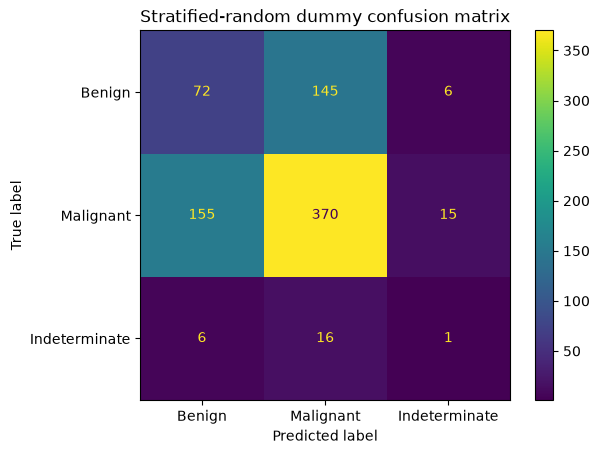

In [32]:
# Confusion matrix for the stratified-random predictor
cm = confusion_matrix(
    y_test,
    dummy_predictions["Stratified-random"],
    labels=classes
)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
).plot()

plt.title("Stratified-random dummy confusion matrix")
plt.show()

In [33]:
# Explicit cost matrix:
# rows = truth, columns = prediction
cost_matrix = pd.DataFrame(
    [
        [0, 1, 5],    # truth: Benign
        [1, 0, 5],    # truth: Malignant
        [5, 50, 0]    # truth: Indeterminate
    ],
    index=classes,
    columns=classes
)

display(cost_matrix)


def expected_cost(y_true, y_pred, cost_matrix):
    costs = [
        cost_matrix.loc[truth, prediction]
        for truth, prediction in zip(y_true, y_pred)
    ]
    return np.mean(costs)


cost_results = []

for name, pred in dummy_predictions.items():
    cost_results.append({
        "Model": name,
        "Expected cost per lesion": expected_cost(
            y_test,
            pred,
            cost_matrix
        )
    })


# Always-Benign
always_benign = np.repeat("Benign", len(y_test))

cost_results.append({
    "Model": "Always-Benign",
    "Expected cost per lesion": expected_cost(
        y_test,
        always_benign,
        cost_matrix
    )
})

cost_results_df = pd.DataFrame(cost_results)

display(cost_results_df)

,Benign,Malignant,Indeterminate
Benign,0,1,5
Malignant,1,0,5
Indeterminate,5,50,0


,Model,Expected cost per lesion
0,Always-Malignant,1.746819
1,Stratified-random,1.571247
2,Uniform-random,2.561069
3,Always-Benign,0.833333


In [34]:
# Compare the three constant predictions under the cost matrix
constant_costs = []

for label in classes:
    prediction = np.repeat(label, len(y_test))

    constant_costs.append({
        "Constant prediction": label,
        "Expected cost per lesion": expected_cost(
            y_test,
            prediction,
            cost_matrix
        )
    })

constant_costs_df = pd.DataFrame(constant_costs)

display(constant_costs_df)

,Constant prediction,Expected cost per lesion
0,Benign,0.833333
1,Malignant,1.746819
2,Indeterminate,4.853690


**Interpretation:** Accuracy and expected clinical cost need not rank the predictors in the same order because the cost matrix assigns much greater weight to some errors than others. In particular, missing a Malignant lesion is substantially more costly than an unnecessary work-up of a Benign lesion. The constant prediction with the lowest expected cost is therefore determined by the explicit cost matrix rather than accuracy alone.

### A3.5 — Is this augmentation label-safe? A quantitative audit

In [35]:
from torchvision.transforms import functional as TF


def circular_mean_hue(hue_degrees):
    angles = np.deg2rad(hue_degrees)

    sin_mean = np.mean(np.sin(angles))
    cos_mean = np.mean(np.cos(angles))

    angle = np.arctan2(sin_mean, cos_mean)
    return np.rad2deg(angle) % 360


def circular_difference(a, b):
    return abs((a - b + 180) % 360 - 180)


def image_hsv_stats(image_array):
    rgb = image_array.astype(np.float32) / 255.0

    max_rgb = rgb.max(axis=2)
    min_rgb = rgb.min(axis=2)
    delta = max_rgb - min_rgb

    hue = np.zeros_like(max_rgb)

    mask = delta != 0

    r, g, b = rgb[..., 0], rgb[..., 1], rgb[..., 2]

    mask_r = mask & (max_rgb == r)
    mask_g = mask & (max_rgb == g)
    mask_b = mask & (max_rgb == b)

    hue[mask_r] = ((g[mask_r] - b[mask_r]) / delta[mask_r]) % 6
    hue[mask_g] = ((b[mask_g] - r[mask_g]) / delta[mask_g]) + 2
    hue[mask_b] = ((r[mask_b] - g[mask_b]) / delta[mask_b]) + 4

    hue *= 60

    valid_hue = hue[mask]
    brightness = max_rgb

    return (
        circular_mean_hue(valid_hue),
        float(np.mean(brightness))
    )


# Use 100 dermoscopic images per class.
colour_data = []

for diagnosis in ["Benign", "Malignant"]:
    rows = (
        metadata[
            (metadata["diagnosis_1"] == diagnosis)
            & (metadata["image_type"] == "dermoscopic")
        ]
        .head(100)
    )

    for _, row in rows.iterrows():
        path = IMAGE_DIR / f"{row['isic_id']}.jpg"

        image = np.array(
            Image.open(path).convert("RGB")
        )

        hue, brightness = image_hsv_stats(image)

        colour_data.append({
            "diagnosis_1": diagnosis,
            "image_id": row["isic_id"],
            "hue": hue,
            "brightness": brightness
        })

colour_stats = pd.DataFrame(colour_data)

class_means = (
    colour_stats
    .groupby("diagnosis_1")[["hue", "brightness"]]
    .mean()
)

hue_gap = circular_difference(
    class_means.loc["Benign", "hue"],
    class_means.loc["Malignant", "hue"]
)

brightness_gap = abs(
    class_means.loc["Benign", "brightness"]
    - class_means.loc["Malignant", "brightness"]
)

print(f"Benign mean hue: {class_means.loc['Benign', 'hue']:.2f}°")
print(f"Malignant mean hue: {class_means.loc['Malignant', 'hue']:.2f}°")
print(f"Benign–Malignant hue gap: {hue_gap:.2f}°")

print(f"Benign mean brightness: {class_means.loc['Benign', 'brightness']:.4f}")
print(f"Malignant mean brightness: {class_means.loc['Malignant', 'brightness']:.4f}")
print(f"Benign–Malignant brightness gap: {brightness_gap:.4f}")

Benign mean hue: 193.31°
Malignant mean hue: 149.83°
Benign–Malignant hue gap: 43.49°
Benign mean brightness: 0.6642
Malignant mean brightness: 0.6828
Benign–Malignant brightness gap: 0.0187


In [36]:
# Measure the change induced by the requested ColorJitter strengths.
# The positive edge of each ColorJitter range is used as a deterministic test.

sample_paths = colour_stats["image_id"].tolist()

hue_strengths = [0.02, 0.05, 0.1, 0.5]
brightness_strengths = [0.1, 0.3, 0.6]

augmentation_results = []

for image_id in sample_paths:
    path = IMAGE_DIR / f"{image_id}.jpg"

    original = Image.open(path).convert("RGB")
    original_array = np.array(original)

    original_hue, original_brightness = image_hsv_stats(
        original_array
    )

    for strength in hue_strengths:
        augmented = TF.adjust_hue(
            original,
            hue_factor=strength
        )

        hue, brightness = image_hsv_stats(
            np.array(augmented)
        )

        augmentation_results.append({
            "augmentation": "hue",
            "strength": strength,
            "change": circular_difference(
                original_hue,
                hue
            )
        })

    for strength in brightness_strengths:
        augmented = TF.adjust_brightness(
            original,
            brightness_factor=1 + strength
        )

        hue, brightness = image_hsv_stats(
            np.array(augmented)
        )

        augmentation_results.append({
            "augmentation": "brightness",
            "strength": strength,
            "change": abs(
                brightness - original_brightness
            )
        })

augmentation_results_df = pd.DataFrame(
    augmentation_results
)

augmentation_summary = (
    augmentation_results_df
    .groupby(["augmentation", "strength"])["change"]
    .mean()
    .reset_index()
)

display(augmentation_summary)

,augmentation,strength,change
0,brightness,0.10,0.064536
1,brightness,0.30,0.182189
2,brightness,0.60,0.272328
3,hue,0.02,6.510128
4,hue,0.05,15.987442
5,hue,0.10,34.687118
6,hue,0.50,177.687276


In [37]:
# Compare augmentation changes with the observed class gaps.

augmentation_summary["exceeds_class_gap"] = False

hue_mask = augmentation_summary["augmentation"] == "hue"
brightness_mask = augmentation_summary["augmentation"] == "brightness"

augmentation_summary.loc[
    hue_mask,
    "exceeds_class_gap"
] = (
    augmentation_summary.loc[hue_mask, "change"]
    > hue_gap
)

augmentation_summary.loc[
    brightness_mask,
    "exceeds_class_gap"
] = (
    augmentation_summary.loc[brightness_mask, "change"]
    > brightness_gap
)

display(augmentation_summary)

,augmentation,strength,change,exceeds_class_gap
0,brightness,0.10,0.064536,True
1,brightness,0.30,0.182189,True
2,brightness,0.60,0.272328,True
3,hue,0.02,6.510128,False
4,hue,0.05,15.987442,False
5,hue,0.10,34.687118,False
6,hue,0.50,177.687276,True


The colour audit compares the Benign–Malignant class gap with the changes introduced by the specified hue and brightness perturbations. Augmentations whose induced change exceeds the observed class gap are potentially risky because they can modify a feature that differs between the classes. Geometric transformations that preserve lesion appearance are generally safer than strong colour transformations. Any augmentation that can alter clinically meaningful colour information should be reviewed and approved before being used for the classification model.

### A3.6 — A lesion-level Dataset

In [38]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from collections import Counter


class LesionDataset(Dataset):
    def __init__(
        self,
        lesion_table,
        img_dir,
        label_col,
        transform=None,
        views=("derm", "clinical")
    ):
        self.table = lesion_table.reset_index(drop=True).copy()
        self.img_dir = Path(img_dir)
        self.label_col = label_col
        self.views = views

        valid_views = {"derm", "clinical"}
        if not set(views).issubset(valid_views):
            raise ValueError(
                f"views must be selected from {valid_views}"
            )

        self.image_columns = {
            "derm": "derm_id",
            "clinical": "clinical_id"
        }

        self.transform = transform or transforms.ToTensor()

        classes = ["Benign", "Malignant", "Indeterminate"]
        self.label_to_int = {
            label: i for i, label in enumerate(classes)
        }

    def __len__(self):
        return len(self.table)

    def __getitem__(self, index):
        row = self.table.iloc[index]

        item = {}

        for view in self.views:
            image_id = row[self.image_columns[view]]
            image_path = self.img_dir / f"{image_id}.jpg"

            if not image_path.exists():
                raise FileNotFoundError(
                    f"Missing {view} image for lesion "
                    f"{row['lesion_id']}: {image_path}"
                )

            image = Image.open(image_path).convert("RGB")
            item[view] = self.transform(image)

        label = row[self.label_col]

        if label not in self.label_to_int:
            raise ValueError(f"Unknown label: {label}")

        item["label"] = self.label_to_int[label]
        item["lesion_id"] = row["lesion_id"]

        return item

In [39]:
# (a) Test DataLoader with batch_size=8

dataset = LesionDataset(
    lesion_table=lesion_table,
    img_dir=IMAGE_DIR,
    label_col="diagnosis_1",
    transform=transforms.ToTensor(),
    views=("derm", "clinical")
)

loader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=False
)

batch = next(iter(loader))

print("Dermoscopic shape:", batch["derm"].shape)
print("Clinical shape:", batch["clinical"].shape)
print("Labels shape:", batch["label"].shape)
print("Number of lesion IDs:", len(batch["lesion_id"]))

assert batch["derm"].shape[0] == 8
assert batch["derm"].shape[1] == 3
assert batch["clinical"].shape[0] == 8
assert batch["clinical"].shape[1] == 3
assert len(batch["lesion_id"]) == 8

expected_ids = lesion_table.iloc[:8]["lesion_id"].tolist()

assert list(batch["lesion_id"]) == expected_ids

print("PASS: batch contains 8 lesions with both image views.")

Dermoscopic shape: torch.Size([8, 3, 450, 600])
Clinical shape: torch.Size([8, 3, 450, 600])
Labels shape: torch.Size([8])
Number of lesion IDs: 8
PASS: batch contains 8 lesions with both image views.


In [40]:
# (b) Iterate over 800 lesions and compare class counts.

subset_table = lesion_table.iloc[:800].copy()

subset_dataset = LesionDataset(
    lesion_table=subset_table,
    img_dir=IMAGE_DIR,
    label_col="diagnosis_1",
    transform=transforms.ToTensor(),
    views=("derm", "clinical")
)

subset_loader = DataLoader(
    subset_dataset,
    batch_size=8,
    shuffle=False
)

seen_labels = []

for batch in subset_loader:
    seen_labels.extend(batch["label"].tolist())

int_to_label = {
    value: key
    for key, value in subset_dataset.label_to_int.items()
}

seen_counts = Counter(
    int_to_label[label]
    for label in seen_labels
)

expected_counts = Counter(
    subset_table["diagnosis_1"]
)

print("Expected:", expected_counts)
print("Seen:", seen_counts)

assert seen_counts == expected_counts

print("PASS: class counts over 800 lesions match the subset.")

Expected: Counter({'Malignant': 541, 'Benign': 238, 'Indeterminate': 21})
Seen: Counter({'Malignant': 541, 'Benign': 238, 'Indeterminate': 21})
PASS: class counts over 800 lesions match the subset.


In [41]:
# (c) Aggregate two-view image probabilities into one lesion prediction.

def aggregate_predictions(image_probs, image_table):
    probs = np.asarray(image_probs)

    table = image_table.reset_index(drop=True).copy()

    if len(probs) != len(table):
        raise ValueError(
            "image_probs and image_table must have the same number of rows."
        )

    table = table.copy()
    table["probability"] = list(probs)

    lesion_probs = (
        table
        .groupby("lesion_id")["probability"]
        .apply(lambda x: np.mean(np.stack(x.values), axis=0))
    )

    lesion_ids = lesion_probs.index.tolist()
    averaged_probs = np.stack(lesion_probs.values)

    predictions = averaged_probs.argmax(axis=1)

    return pd.DataFrame({
        "lesion_id": lesion_ids,
        "prediction": predictions,
        "probabilities": list(averaged_probs)
    })


# Synthetic two-view probabilities for two lesions
synthetic_table = pd.DataFrame({
    "lesion_id": ["L1", "L1", "L2", "L2"],
    "image_type": ["derm", "clinical", "derm", "clinical"]
})

synthetic_probs = np.array([
    [0.10, 0.80, 0.10],
    [0.20, 0.70, 0.10],
    [0.70, 0.20, 0.10],
    [0.60, 0.30, 0.10]
])

aggregated = aggregate_predictions(
    synthetic_probs,
    synthetic_table
)

display(aggregated)

assert len(aggregated) == 2
assert aggregated.loc[
    aggregated["lesion_id"] == "L1", "prediction"
].iloc[0] == 1

assert aggregated.loc[
    aggregated["lesion_id"] == "L2", "prediction"
].iloc[0] == 0

print("PASS: two image-view probabilities are averaged into one lesion prediction.")

,lesion_id,prediction,probabilities
0,L1,1,"[0.15000000000000002, 0.75, 0.1]"
1,L2,0,"[0.6499999999999999, 0.25, 0.1]"


PASS: two image-view probabilities are averaged into one lesion prediction.


The correct unit of evaluation is the lesion because each lesion has two related image views. Evaluating images independently can give the same lesion disproportionate influence and can also introduce leakage when its two views are split across train and test. Lesion-level aggregation therefore gives one prediction per clinical lesion and matches the intended evaluation unit.